# Thesis result plotting notebook

This notebook uses the finalized CSV/JSON outputs and writes figures to:

`/home/keen/HiDDeN/output/figures`

The plotting choices are split into:

- **Main-text candidates**
  - rectangular removal: BER vs. removal ratio
  - rectangular removal: attack-only PSNR vs. removal ratio
  - sparse masks: BER vs. attack-only PSNR
  - paired bootstrap differences for selected sparse-mask comparisons
- **Appendix candidates**
  - SSIM-based variants
  - final/end-to-end PSNR and SSIM
  - clean validation plots

The notebook deliberately keeps each chart as a separate figure rather than using subplots.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## 1. Paths

In [2]:
PROJECT_ROOT = Path("/home/keen/HiDDeN")

RECTANGULAR_CSV = (
    PROJECT_ROOT
    / "output"
    / "csv"
    / "rectangular_mask_results.csv"
)

SPARSE_CSV = (
    PROJECT_ROOT
    / "output"
    / "csv"
    / "sparse_mask_results.csv"
)

VALIDATION_CSV = (
    PROJECT_ROOT
    / "output"
    / "csv"
    / "validation_results.csv"
)

BOOTSTRAP_JSON = (
    PROJECT_ROOT
    / "bootstrap_results_metrics"
    / "bootstrap_grid_results.json"
)

BOOTSTRAP_CSV = (
    PROJECT_ROOT
    / "bootstrap_results_metrics"
    / "bootstrap_grid_summary.csv"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "output"
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Figure output:", FIGURE_DIR)

Figure output: /home/keen/HiDDeN/output/figures


## 2. Load data

In [3]:
rect_df = pd.read_csv(RECTANGULAR_CSV)
sparse_df = pd.read_csv(SPARSE_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
bootstrap_df = pd.read_csv(BOOTSTRAP_CSV)

with open(
    BOOTSTRAP_JSON,
    "r",
    encoding="utf-8",
) as f:
    bootstrap_json = json.load(f)

print("rectangular:", rect_df.shape)
print("sparse:", sparse_df.shape)
print("validation:", validation_df.shape)
print("bootstrap:", bootstrap_df.shape)
print("bootstrap JSON models:", list(bootstrap_json))

rectangular: (180, 10)
sparse: (96, 10)
validation: (4, 4)
bootstrap: (480, 14)
bootstrap JSON models: ['3k_baseline', '3k_gaussian_blur', '3k_haar_wavelet', '3k_frozen_pretrained_unet_eval_aligned']


## 3. Sanity checks

In [4]:
EXPECTED_RECTANGULAR_ROWS = 4 * 5 * 9
EXPECTED_SPARSE_ROWS = 4 * 4 * 2 * 3
EXPECTED_VALIDATION_ROWS = 4
EXPECTED_BOOTSTRAP_ROWS = 4 * 4 * 2 * 3 * 5

assert len(rect_df) == EXPECTED_RECTANGULAR_ROWS, (
    len(rect_df),
    EXPECTED_RECTANGULAR_ROWS,
)

assert len(sparse_df) == EXPECTED_SPARSE_ROWS, (
    len(sparse_df),
    EXPECTED_SPARSE_ROWS,
)

assert len(validation_df) == EXPECTED_VALIDATION_ROWS, (
    len(validation_df),
    EXPECTED_VALIDATION_ROWS,
)

assert len(bootstrap_df) == EXPECTED_BOOTSTRAP_ROWS, (
    len(bootstrap_df),
    EXPECTED_BOOTSTRAP_ROWS,
)

required_rect_columns = {
    "model",
    "attack",
    "removal_ratio",
    "PSNR_final",
    "SSIM_final",
    "PSNR_attack",
    "SSIM_attack",
    "BER",
}

required_sparse_columns = {
    "model",
    "mask_type",
    "density",
    "attack",
    "PSNR_final",
    "SSIM_final",
    "PSNR_attack",
    "SSIM_attack",
    "BER",
}

required_validation_columns = {
    "model",
    "PSNR_embed",
    "SSIM_embed",
    "BER",
}

required_bootstrap_columns = {
    "model",
    "attack",
    "density",
    "comparison",
    "metric",
    "mean_difference",
    "ci_95_low",
    "ci_95_high",
}

assert required_rect_columns.issubset(rect_df.columns)
assert required_sparse_columns.issubset(sparse_df.columns)
assert required_validation_columns.issubset(validation_df.columns)
assert required_bootstrap_columns.issubset(bootstrap_df.columns)

assert not rect_df.duplicated(
    ["model", "attack", "removal_ratio"]
).any()

assert not sparse_df.duplicated(
    ["model", "attack", "density", "mask_type"]
).any()

assert not bootstrap_df.duplicated(
    [
        "model",
        "attack",
        "density",
        "comparison",
        "metric",
    ]
).any()

print("All sanity checks passed.")

All sanity checks passed.


## 4. Plot style and helpers

In [5]:
plt.rcParams.update(
    {
        "figure.figsize": (7.8, 5.2),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "legend.fontsize": 10.5,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }
)

MODEL_ORDER = [
    "Baseline",
    "Gaussian Blur",
    "Haar Wavelet",
    "Frozen UNet",
]

ATTACK_ORDER_RECT = [
    "mean",
    "telea",
    "navier",
    "shiftmap",
    "diffusion",
]

ATTACK_ORDER_SPARSE = [
    "mean",
    "telea",
    "navier",
    "diffusion",
]

MASK_ORDER = [
    "Random",
    "O150",
    "O300",
]

MODEL_MARKERS = {
    "Baseline": "o",
    "Gaussian Blur": "s",
    "Haar Wavelet": "^",
    "Frozen UNet": "D",
}

DISPLAY_ATTACK = {
    "mean": "Mean Fill",
    "telea": "Telea",
    "navier": "Navier–Stokes",
    "shiftmap": "ShiftMap",
    "diffusion": "Homogeneous Diffusion",
}

DISPLAY_ATTACK_SHORT = {
    "mean": "Mean",
    "telea": "Telea",
    "navier": "Navier",
    "diffusion": "Diffusion",
}

DISPLAY_MODEL = {
    "Baseline": "Baseline",
    "Gaussian Blur": "Gaussian Blur",
    "Haar Wavelet": "Haar Wavelet",
    "Frozen UNet": "Frozen U-Net",
}

MASK_STYLE = {
    "Random": {
        "marker": "^",
        "facecolor": "none",
        "edgecolor": "black",
        "linewidth": 1.8,
    },
    "O150": {
        "marker": "o",
        "facecolor": "none",
        "edgecolor": "gray",
        "linewidth": 1.8,
    },
    "O300": {
        "marker": "o",
        "facecolor": "none",
        "edgecolor": "black",
        "linewidth": 2.0,
    },
}


def save_figure(fig, filename):
    path = FIGURE_DIR / filename

    fig.savefig(
        path,
        bbox_inches="tight",
    )

    print("saved:", path)

    return path


def padded_limits(values, lower=None, upper=None, fraction=0.06):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    data_min = values.min()
    data_max = values.max()

    span = data_max - data_min
    if span == 0:
        span = max(abs(data_max), 1.0)

    lo = data_min - fraction * span
    hi = data_max + fraction * span

    if lower is not None:
        lo = lower

    if upper is not None:
        hi = upper

    return lo, hi


# Shared rectangular limits make separate attack figures directly comparable.
RECT_BER_YLIM = padded_limits(
    rect_df["BER"],
    lower=0.0,
    fraction=0.08,
)

RECT_PSNR_ATTACK_YLIM = padded_limits(
    rect_df["PSNR_attack"],
    fraction=0.05,
)

print("Shared rectangular BER ylim:", RECT_BER_YLIM)
print("Shared rectangular PSNR_attack ylim:", RECT_PSNR_ATTACK_YLIM)

Shared rectangular BER ylim: (0.0, 0.4850844444444448)
Shared rectangular PSNR_attack ylim: (9.646186530510585, 29.850157140970232)


## 5. Rectangular removal sweep

For the main text, the two most useful plots are usually:

1. **BER vs. removal ratio**
2. **PSNR_attack vs. removal ratio**

`PSNR_attack` and `SSIM_attack` measure encoded → attacked distortion, while
`PSNR_final` and `SSIM_final` measure cover → attacked end-to-end fidelity.

In [6]:
def plot_rectangular_metric(
    attack,
    metric,
    ylabel,
    filename=None,
    title=None,
    ylim=None,
):
    subset = rect_df[
        rect_df["attack"] == attack
    ].copy()

    fig, ax = plt.subplots(
        figsize=(7.8, 5.2)
    )

    for model in MODEL_ORDER:
        model_df = (
            subset[
                subset["model"] == model
            ]
            .sort_values("removal_ratio")
        )

        ax.plot(
            model_df["removal_ratio"],
            model_df[metric],
            marker=MODEL_MARKERS[model],
            linewidth=1.9,
            markersize=5.5,
            label=DISPLAY_MODEL[model],
        )

    ax.set_xlabel(
        "Removal ratio",
        fontsize=13,
    )
    ax.set_ylabel(
        ylabel,
        fontsize=13,
    )

    if title is None:
        title = DISPLAY_ATTACK.get(
            attack,
            attack,
        )

    ax.set_title(
        title,
        fontsize=14,
        pad=10,
    )

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.tick_params(
        axis="both",
        labelsize=11,
    )

    ax.grid(
        alpha=0.22,
    )

    ax.legend(
        frameon=False,
        loc="best",
    )

    fig.tight_layout()

    if filename is not None:
        save_figure(
            fig,
            filename,
        )

    return fig, ax

### 5.1 Main-text candidate: BER curves

saved: /home/keen/HiDDeN/output/figures/rectangular_ber_mean.pdf
saved: /home/keen/HiDDeN/output/figures/rectangular_ber_telea.pdf
saved: /home/keen/HiDDeN/output/figures/rectangular_ber_navier.pdf
saved: /home/keen/HiDDeN/output/figures/rectangular_ber_shiftmap.pdf
saved: /home/keen/HiDDeN/output/figures/rectangular_ber_diffusion.pdf


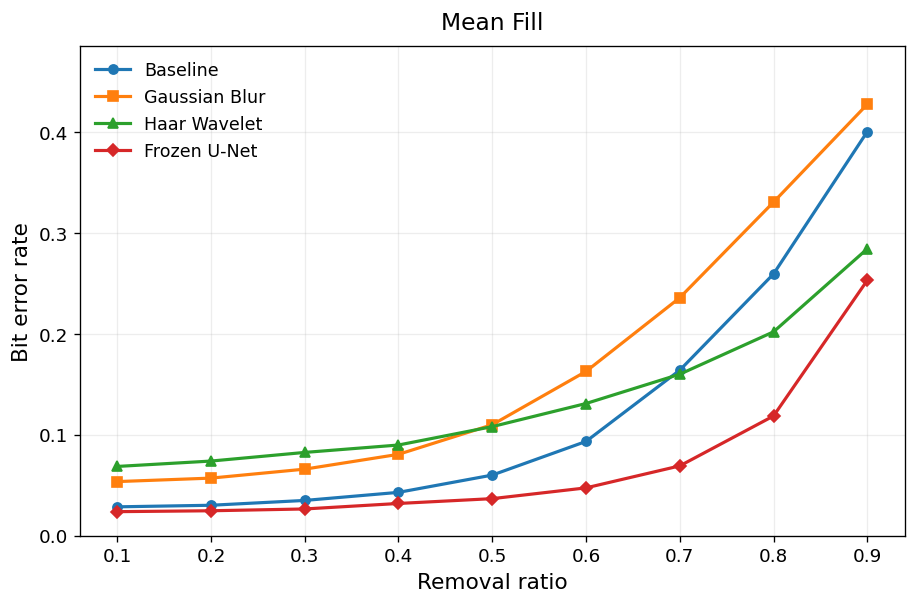

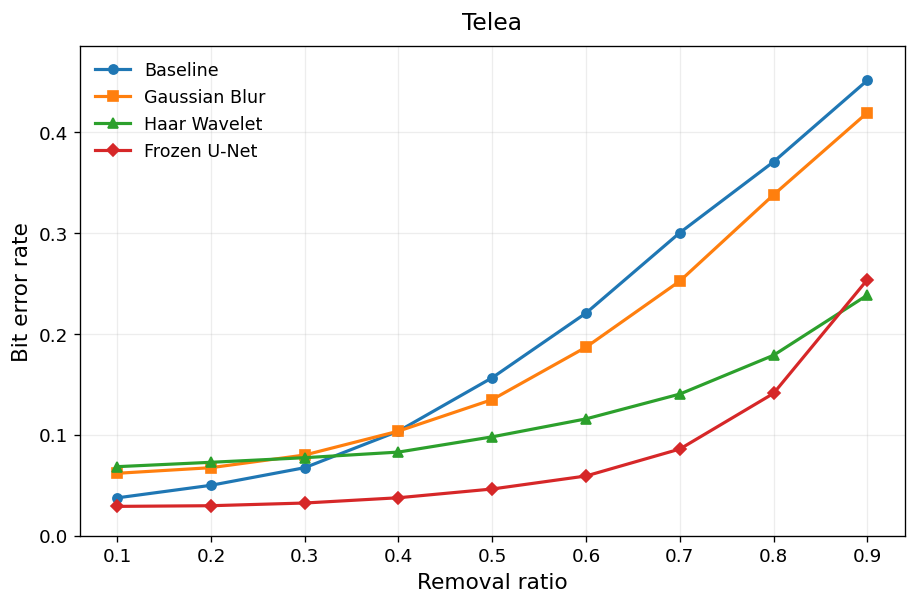

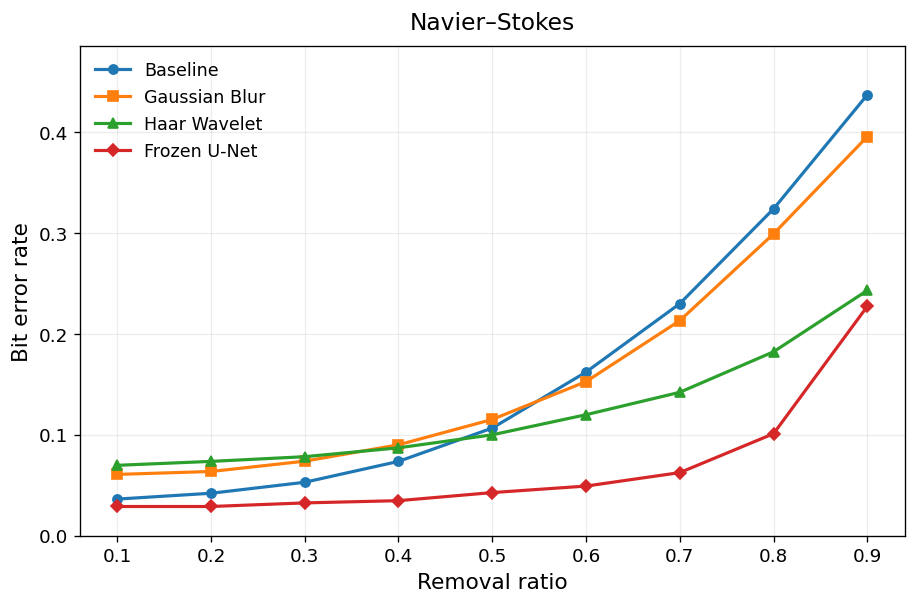

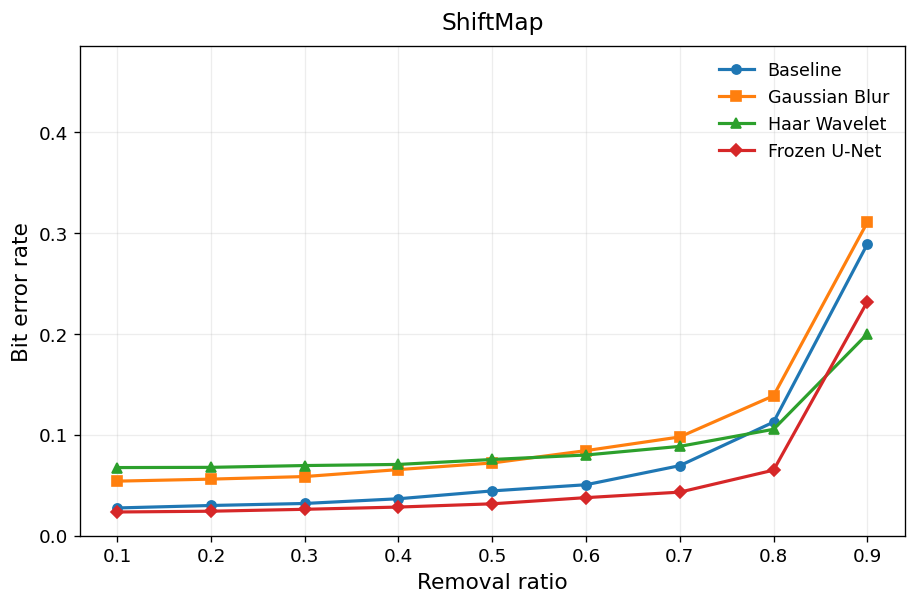

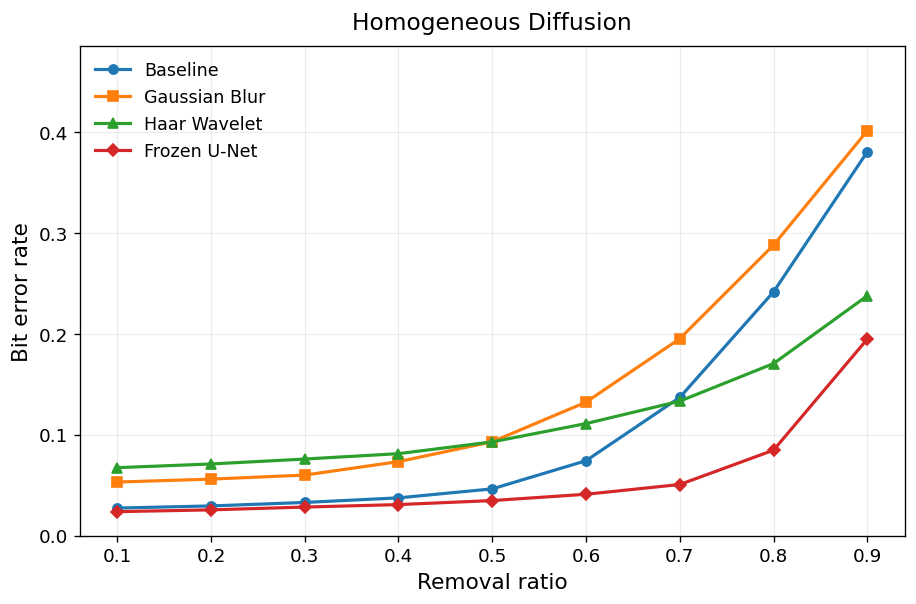

In [7]:
for attack in ATTACK_ORDER_RECT:
    plot_rectangular_metric(
        attack=attack,
        metric="BER",
        ylabel="Bit error rate",
        ylim=RECT_BER_YLIM,
        filename=(
            f"rectangular_ber_{attack}.pdf"
        ),
    )

plt.show()

### 5.2 Main-text candidate: attack-only PSNR curves

saved: /home/keen/HiDDeN/output/figures/rectangular_psnr_attack_mean.pdf
saved: /home/keen/HiDDeN/output/figures/rectangular_psnr_attack_telea.pdf
saved: /home/keen/HiDDeN/output/figures/rectangular_psnr_attack_navier.pdf
saved: /home/keen/HiDDeN/output/figures/rectangular_psnr_attack_shiftmap.pdf
saved: /home/keen/HiDDeN/output/figures/rectangular_psnr_attack_diffusion.pdf


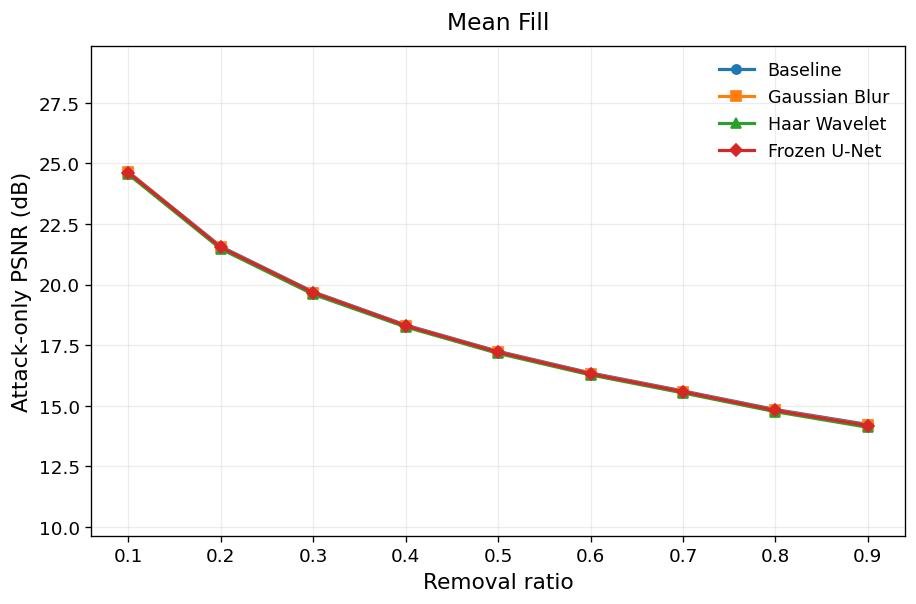

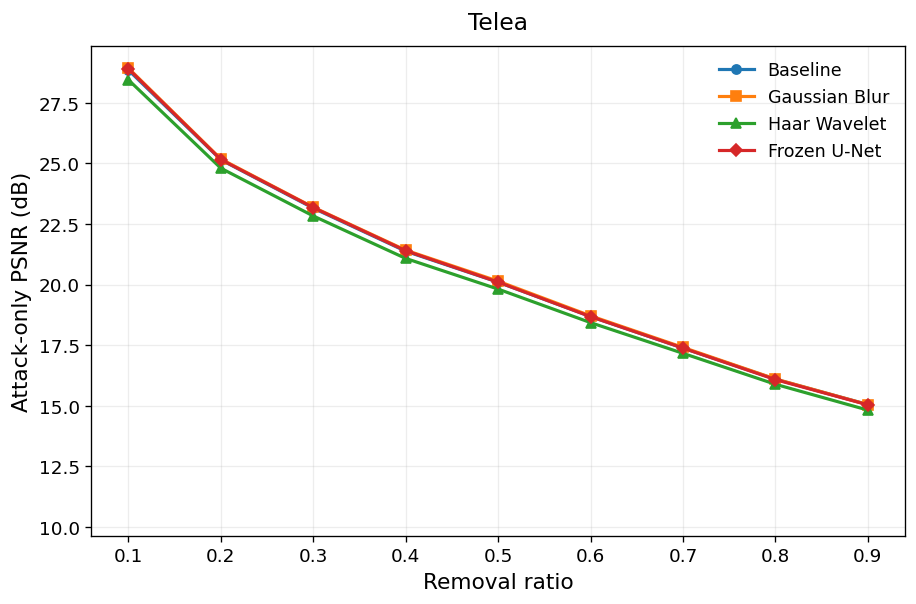

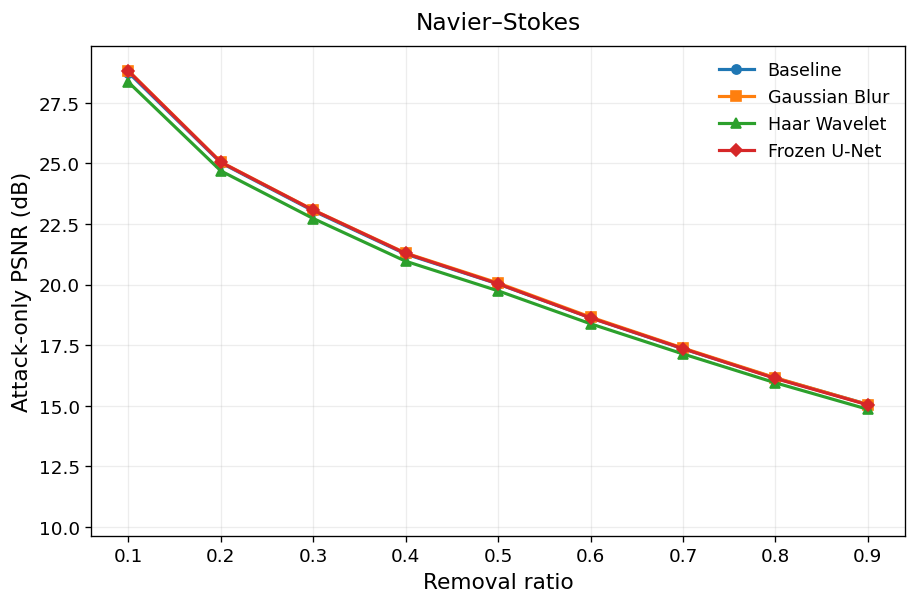

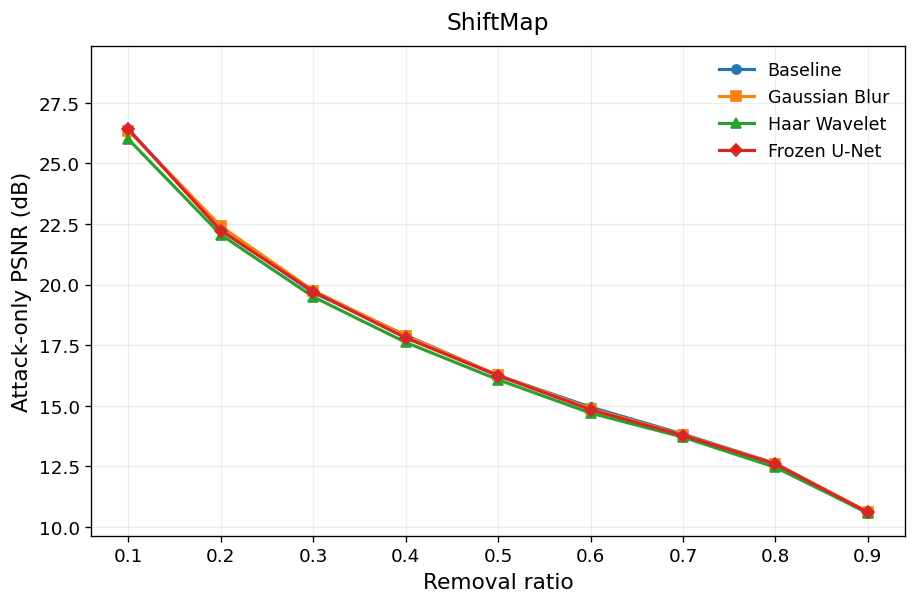

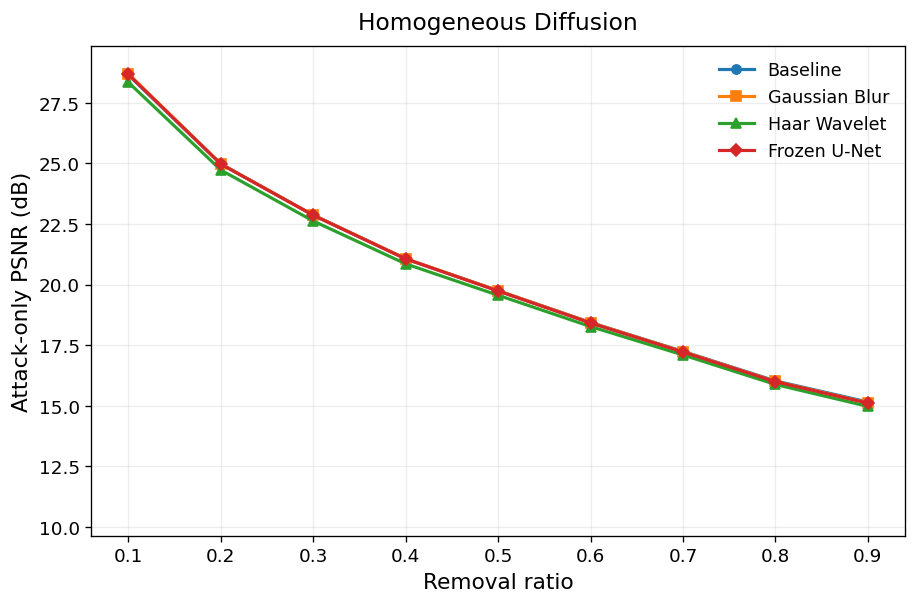

In [8]:
for attack in ATTACK_ORDER_RECT:
    plot_rectangular_metric(
        attack=attack,
        metric="PSNR_attack",
        ylabel="Attack-only PSNR (dB)",
        ylim=RECT_PSNR_ATTACK_YLIM,
        filename=(
            f"rectangular_psnr_attack_{attack}.pdf"
        ),
    )

plt.show()

### 5.3 Appendix candidates: SSIM_attack and final fidelity

In [9]:
# Uncomment the blocks you want to export.

# for attack in ATTACK_ORDER_RECT:
#     plot_rectangular_metric(
#         attack=attack,
#         metric="SSIM_attack",
#         ylabel="Attack-only SSIM",
#         filename=(
#             f"rectangular_ssim_attack_{attack}.pdf"
#         ),
#     )

# for attack in ATTACK_ORDER_RECT:
#     plot_rectangular_metric(
#         attack=attack,
#         metric="PSNR_final",
#         ylabel="Final PSNR (dB)",
#         filename=(
#             f"rectangular_psnr_final_{attack}.pdf"
#         ),
#     )

# for attack in ATTACK_ORDER_RECT:
#     plot_rectangular_metric(
#         attack=attack,
#         metric="SSIM_final",
#         ylabel="Final SSIM",
#         filename=(
#             f"rectangular_ssim_final_{attack}.pdf"
#         ),
#     )

# plt.show()

## 6. Sparse-mask trade-off plots

Each figure below fixes **one model and one density**.  
Within the figure, each reconstruction operator forms one line through:

`Random → O150 → O300`

The horizontal axis is attack-only PSNR and the vertical axis is BER.
This makes it easy to see that better reconstruction quality does not
necessarily imply better watermark recovery.

In [10]:
def plot_sparse_tradeoff(
    model,
    density,
    filename=None,
):
    subset = sparse_df[
        (sparse_df["model"] == model)
        & (
            np.isclose(
                sparse_df["density"],
                density,
            )
        )
    ].copy()

    fig, ax = plt.subplots(
        figsize=(8.8, 5.8)
    )

    attack_handles = []

    for attack in ATTACK_ORDER_SPARSE:

        attack_df = subset[
            subset["attack"] == attack
        ].copy()

        attack_df["mask_type"] = (
            pd.Categorical(
                attack_df["mask_type"],
                categories=MASK_ORDER,
                ordered=True,
            )
        )

        attack_df = (
            attack_df
            .sort_values("mask_type")
        )

        # Line color identifies the reconstruction operator.
        line, = ax.plot(
            attack_df["PSNR_attack"],
            attack_df["BER"],
            linewidth=1.8,
            label=DISPLAY_ATTACK[attack],
            zorder=1,
        )

        attack_handles.append(line)

        # Marker shape/edge identifies the mask configuration.
        for _, row in attack_df.iterrows():
            mask_type = str(
                row["mask_type"]
            )

            style = MASK_STYLE[
                mask_type
            ]

            ax.scatter(
                row["PSNR_attack"],
                row["BER"],
                marker=style["marker"],
                s=92,
                facecolors=style["facecolor"],
                edgecolors=style["edgecolor"],
                linewidths=style["linewidth"],
                zorder=3,
            )

    ax.set_xlabel(
        "Attack-only PSNR (dB)",
        fontsize=13,
    )

    ax.set_ylabel(
        "Bit error rate",
        fontsize=13,
    )

    ax.set_title(
        f"{DISPLAY_MODEL[model]}, "
        f"retained density $d={density:.1f}$",
        fontsize=14,
        pad=10,
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
    )

    ax.grid(
        alpha=0.22,
    )

    # Legend 1: reconstruction operator.
    legend_attack = ax.legend(
        handles=attack_handles,
        title="Reconstruction",
        fontsize=10.5,
        title_fontsize=11,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
    )

    ax.add_artist(
        legend_attack
    )

    # Legend 2: mask configuration.
    mask_handles = [
        Line2D(
            [0],
            [0],
            marker="^",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=1.8,
            markersize=9,
            label="Random",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor="gray",
            markeredgewidth=1.8,
            markersize=9,
            label="O150",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=2.0,
            markersize=9,
            label="O300",
        ),
    ]

    ax.legend(
        handles=mask_handles,
        title="Mask",
        fontsize=10.5,
        title_fontsize=11,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.50),
        borderaxespad=0,
    )

    # Reserve room for the two legends.
    fig.tight_layout(
        rect=[
            0,
            0,
            0.78,
            1,
        ]
    )

    if filename is not None:
        save_figure(
            fig,
            filename,
        )

    return fig, ax

### 6.1 Generate sparse trade-off figures

saved: /home/keen/HiDDeN/output/figures/sparse_tradeoff_baseline_d0.1.pdf
saved: /home/keen/HiDDeN/output/figures/sparse_tradeoff_baseline_d0.3.pdf
saved: /home/keen/HiDDeN/output/figures/sparse_tradeoff_gaussian_blur_d0.1.pdf
saved: /home/keen/HiDDeN/output/figures/sparse_tradeoff_gaussian_blur_d0.3.pdf
saved: /home/keen/HiDDeN/output/figures/sparse_tradeoff_haar_wavelet_d0.1.pdf
saved: /home/keen/HiDDeN/output/figures/sparse_tradeoff_haar_wavelet_d0.3.pdf
saved: /home/keen/HiDDeN/output/figures/sparse_tradeoff_frozen_unet_d0.1.pdf
saved: /home/keen/HiDDeN/output/figures/sparse_tradeoff_frozen_unet_d0.3.pdf


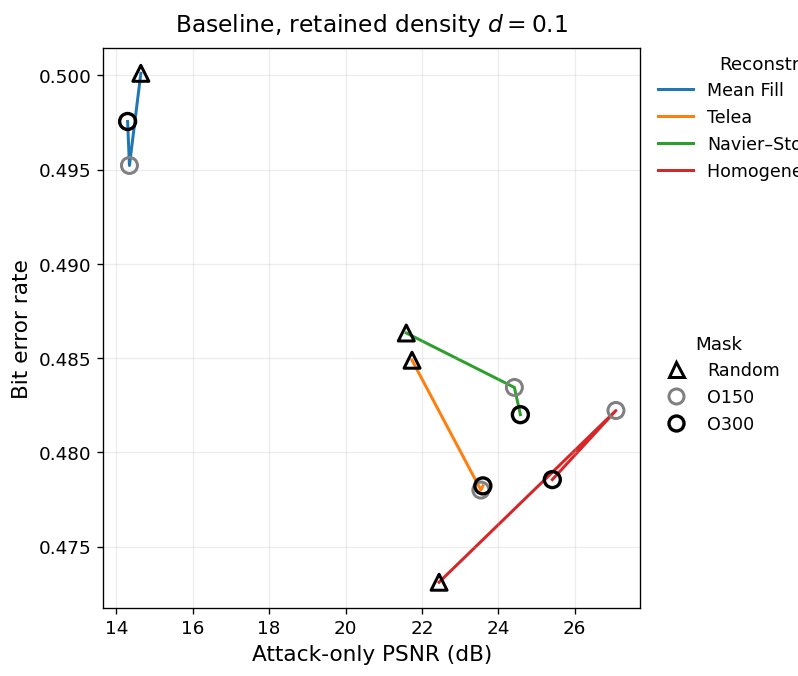

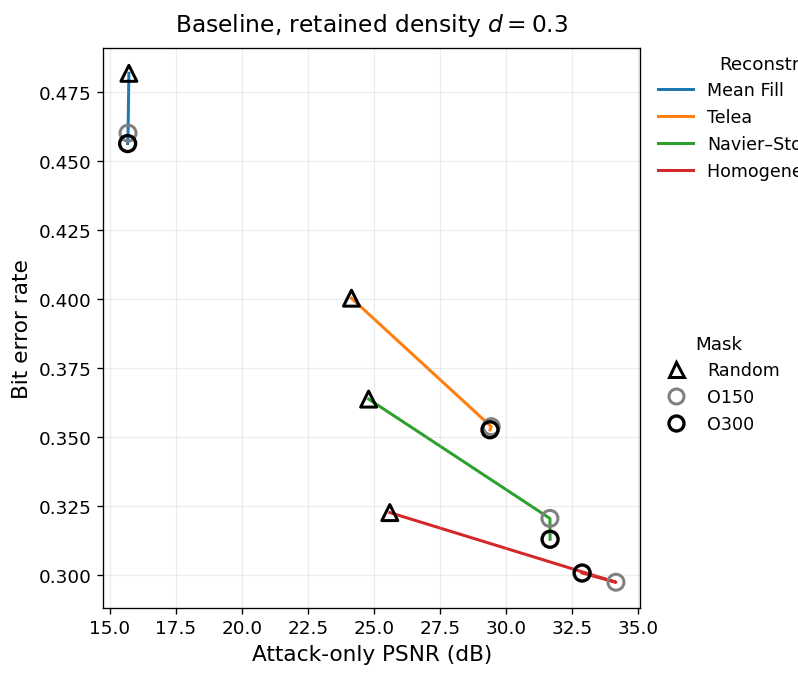

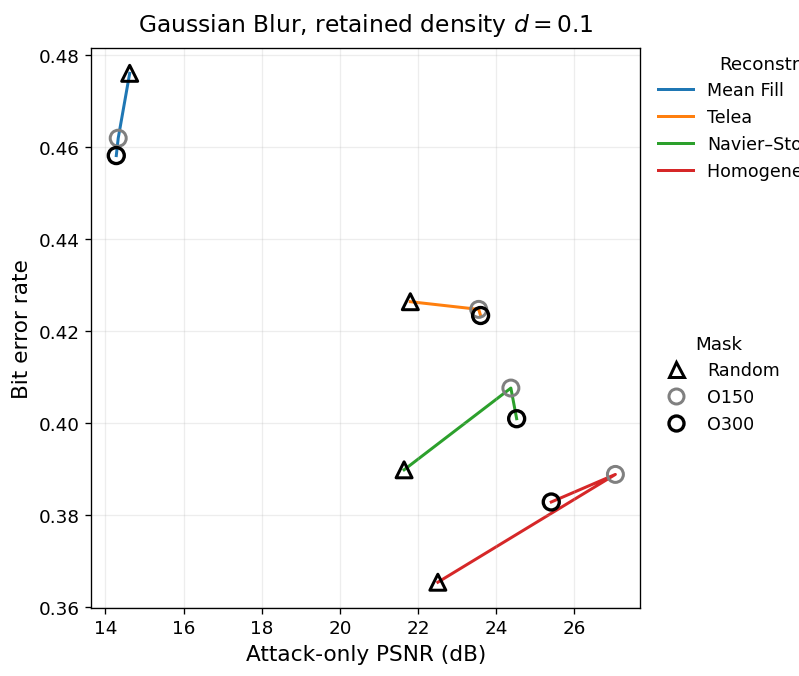

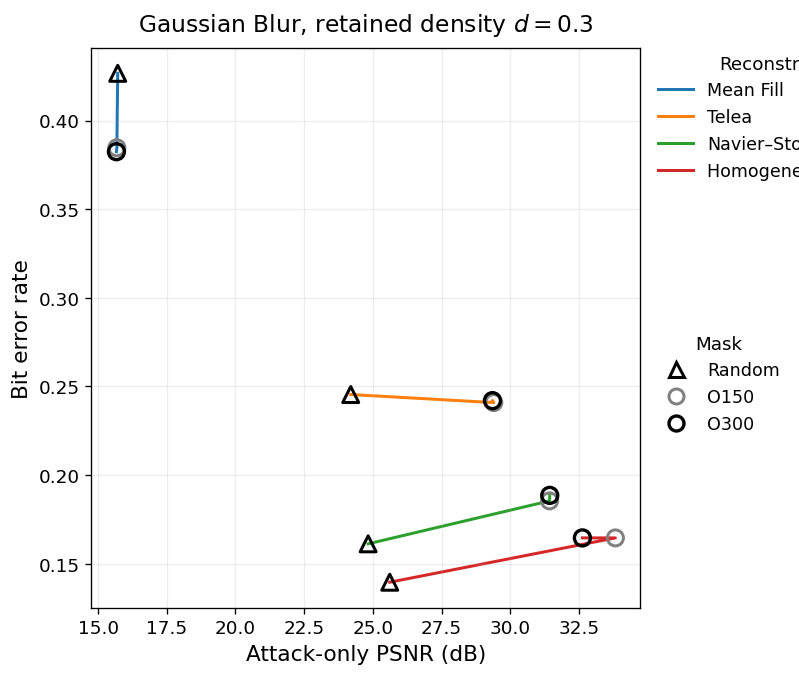

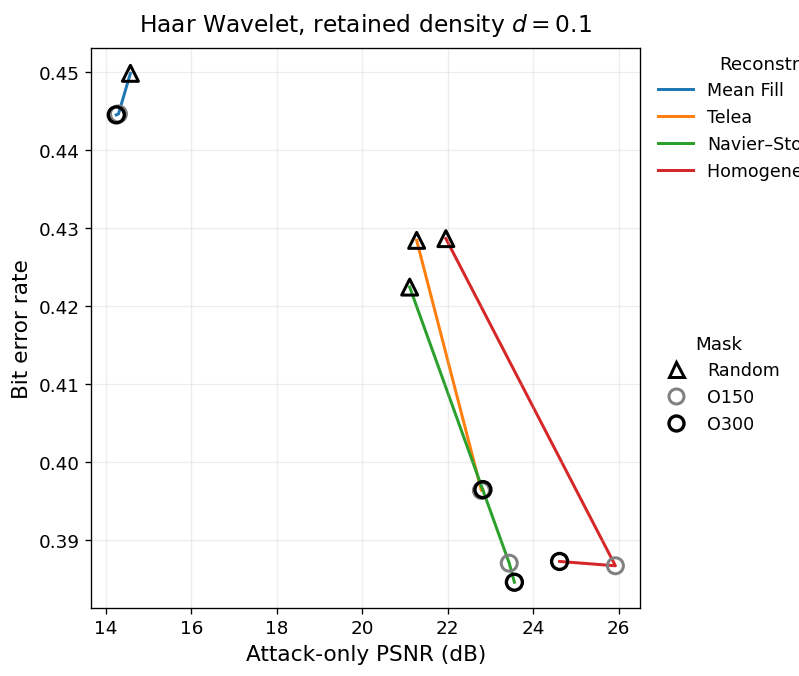

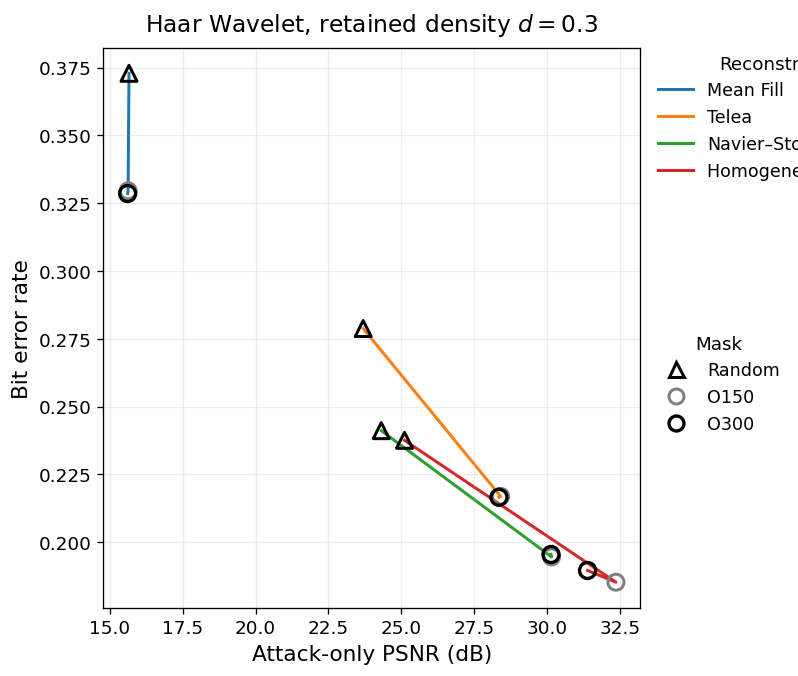

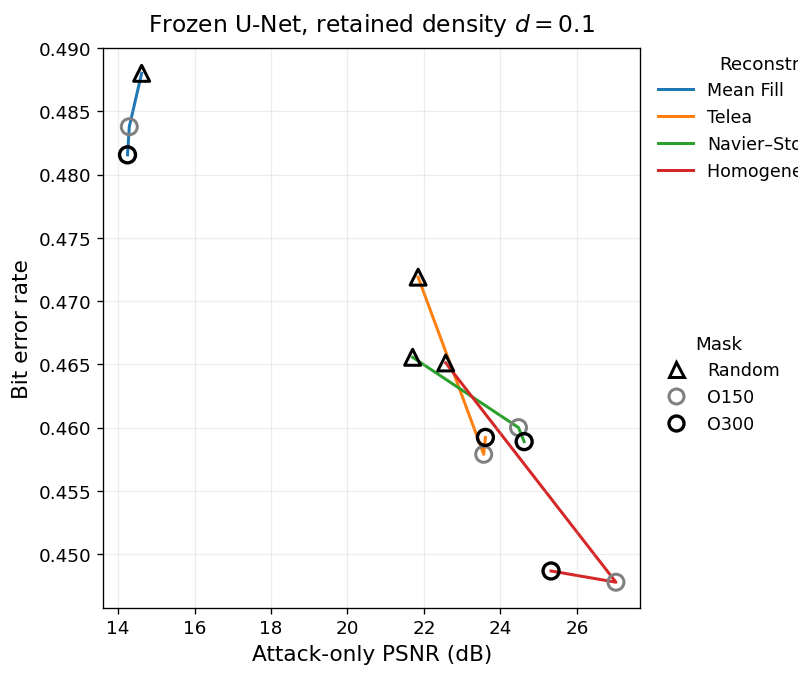

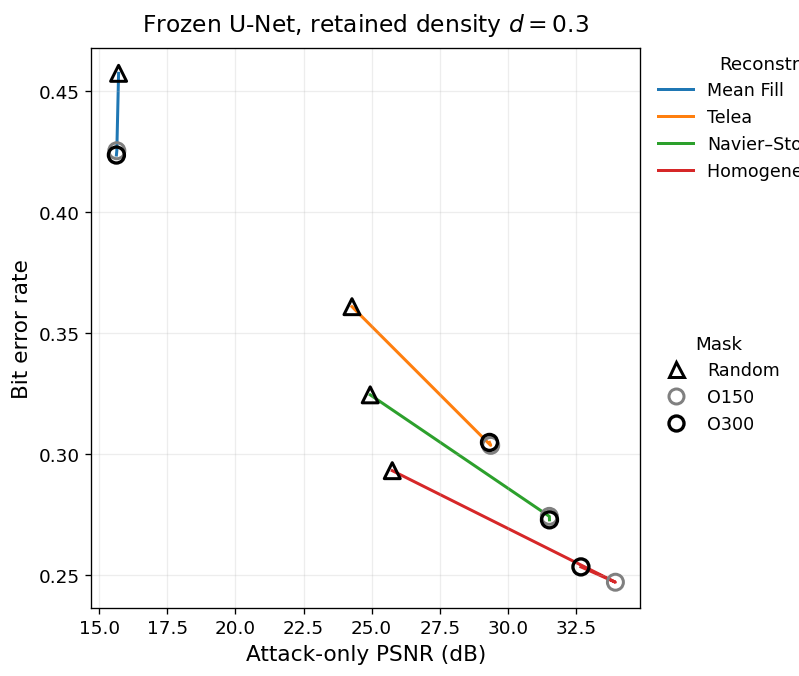

In [11]:
for model in MODEL_ORDER:
    for density in [0.1, 0.3]:
        safe_model = (
            model.lower()
            .replace(" ", "_")
        )

        plot_sparse_tradeoff(
            model=model,
            density=density,
            filename=(
                f"sparse_tradeoff_"
                f"{safe_model}_"
                f"d{density:.1f}.pdf"
            ),
        )

plt.show()

## 7. Sparse direct comparison by mask type

This view is useful when the text discusses the effect of mask optimization
directly. It fixes one model, one attack, and one density, and compares
Random / O150 / O300 for one metric.

In [12]:
def plot_sparse_mask_comparison(
    model,
    attack,
    density,
    metric,
    ylabel,
    filename=None,
):
    subset = sparse_df[
        (sparse_df["model"] == model)
        & (
            sparse_df["attack"]
            == attack
        )
        & (
            np.isclose(
                sparse_df["density"],
                density,
            )
        )
    ].copy()

    subset["mask_type"] = (
        pd.Categorical(
            subset["mask_type"],
            categories=MASK_ORDER,
            ordered=True,
        )
    )

    subset = (
        subset
        .sort_values("mask_type")
    )

    fig, ax = plt.subplots()

    ax.plot(
        subset["mask_type"].astype(str),
        subset[metric],
        marker="o",
        linewidth=1.8,
    )

    ax.set_xlabel(
        "Mask configuration"
    )
    ax.set_ylabel(
        ylabel
    )

    ax.set_title(
        f"{DISPLAY_MODEL[model]} – "
        f"{DISPLAY_ATTACK[attack]}, "
        f"d = {density:.1f}"
    )

    ax.grid(
        alpha=0.25,
        axis="y",
    )

    fig.tight_layout()

    if filename is not None:
        save_figure(
            fig,
            filename,
        )

    return fig, ax

### 7.1 Example direct comparison

saved: /home/keen/HiDDeN/output/figures/sparse_direct_baseline_diffusion_d0.1_psnr_attack.pdf


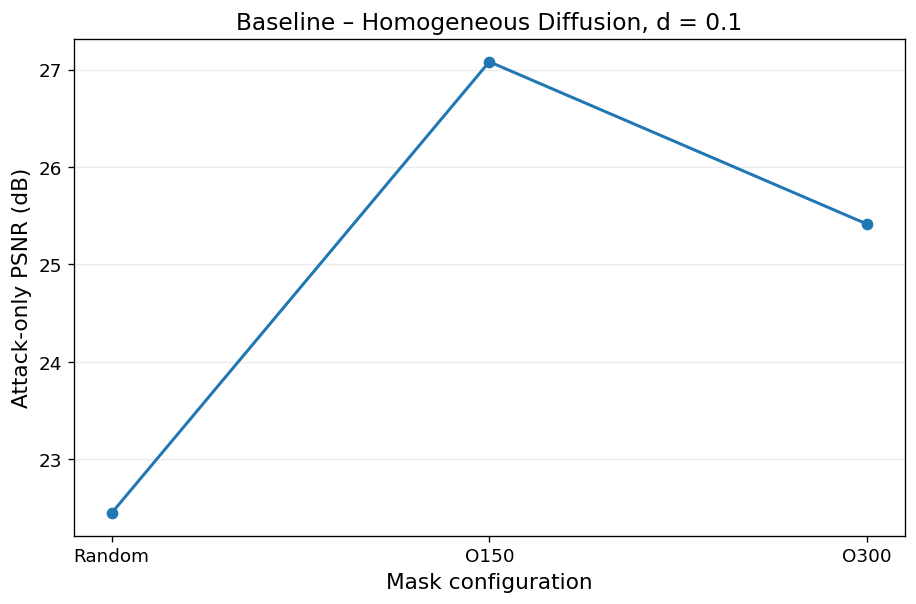

In [13]:
plot_sparse_mask_comparison(
    model="Baseline",
    attack="diffusion",
    density=0.1,
    metric="PSNR_attack",
    ylabel="Attack-only PSNR (dB)",
    filename=(
        "sparse_direct_"
        "baseline_diffusion_"
        "d0.1_psnr_attack.pdf"
    ),
)

plt.show()

## 8. Paired bootstrap difference plots

The bootstrap CSV contains paired image-level differences for:

- `Random -> O150`
- `Random -> O300`
- `O150 -> O300`

For a selected model/comparison/metric, the plot below shows the mean
difference and its 95% bootstrap CI across attack × density conditions.

Interpretation examples:

- positive ΔPSNR / ΔSSIM = reconstruction quality increased
- positive ΔBER = BER increased, i.e. watermark recovery became worse
- negative ΔBER = BER decreased, i.e. watermark recovery improved

In [14]:
MODEL_TO_BOOTSTRAP = {
    "Baseline":
        "3k_baseline",

    "Gaussian Blur":
        "3k_gaussian_blur",

    "Haar Wavelet":
        "3k_haar_wavelet",

    "Frozen UNet":
        "3k_frozen_pretrained_unet_eval_aligned",
}


def bootstrap_shared_ylim(
    comparison,
    metric,
    fraction=0.08,
):
    subset = bootstrap_df[
        (
            bootstrap_df["comparison"]
            == comparison
        )
        & (
            bootstrap_df["metric"]
            == metric
        )
    ]

    values = np.concatenate(
        [
            subset["ci_95_low"].to_numpy(
                dtype=float
            ),
            subset["ci_95_high"].to_numpy(
                dtype=float
            ),
            np.array([0.0]),
        ]
    )

    return padded_limits(
        values,
        fraction=fraction,
    )


BOOTSTRAP_YLIMS = {
    ("Random -> O150", "psnr_attack"):
        bootstrap_shared_ylim(
            "Random -> O150",
            "psnr_attack",
        ),

    ("Random -> O150", "ber"):
        bootstrap_shared_ylim(
            "Random -> O150",
            "ber",
        ),

    ("O150 -> O300", "psnr_attack"):
        bootstrap_shared_ylim(
            "O150 -> O300",
            "psnr_attack",
        ),
}


def plot_bootstrap_differences(
    model,
    comparison,
    metric,
    ylabel,
    filename=None,
    ylim=None,
):
    bootstrap_model = (
        MODEL_TO_BOOTSTRAP[model]
    )

    subset = bootstrap_df[
        (
            bootstrap_df["model"]
            == bootstrap_model
        )
        & (
            bootstrap_df["comparison"]
            == comparison
        )
        & (
            bootstrap_df["metric"]
            == metric
        )
    ].copy()

    attack_rank = {
        attack: i
        for i, attack
        in enumerate(
            ATTACK_ORDER_SPARSE
        )
    }

    subset["attack_rank"] = (
        subset["attack"].map(
            attack_rank
        )
    )

    subset = subset.sort_values(
        [
            "attack_rank",
            "density",
        ]
    ).reset_index(
        drop=True
    )

    labels = [
        (
            f"{DISPLAY_ATTACK_SHORT[a]}\n"
            rf"$d={d:.1f}$"
        )
        for a, d
        in zip(
            subset["attack"],
            subset["density"],
        )
    ]

    x = np.arange(
        len(subset)
    )

    mean = (
        subset["mean_difference"]
        .to_numpy()
    )

    low = (
        subset["ci_95_low"]
        .to_numpy()
    )

    high = (
        subset["ci_95_high"]
        .to_numpy()
    )

    yerr = np.vstack(
        [
            mean - low,
            high - mean,
        ]
    )

    fig, ax = plt.subplots(
        figsize=(9.2, 5.3)
    )

    ax.errorbar(
        x,
        mean,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=6,
        linewidth=1.5,
    )

    ax.axhline(
        0,
        linewidth=1.1,
        linestyle="--",
        alpha=0.75,
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        labels,
        rotation=0,
        ha="center",
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13,
    )

    clean_comparison = (
        comparison.replace(
            "->",
            "vs.",
        )
    )

    ax.set_title(
        f"{DISPLAY_MODEL[model]} — "
        f"{clean_comparison}",
        fontsize=14,
        pad=10,
    )

    if ylim is None:
        ylim = BOOTSTRAP_YLIMS.get(
            (
                comparison,
                metric,
            )
        )

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.tick_params(
        axis="both",
        labelsize=11,
    )

    ax.grid(
        alpha=0.22,
        axis="y",
    )

    fig.tight_layout()

    if filename is not None:
        save_figure(
            fig,
            filename,
        )

    return fig, ax

### 8.1 Recommended bootstrap figures

saved: /home/keen/HiDDeN/output/figures/bootstrap_baseline_random_o150_psnr_attack.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_gaussian_blur_random_o150_psnr_attack.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_haar_wavelet_random_o150_psnr_attack.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_frozen_unet_random_o150_psnr_attack.pdf


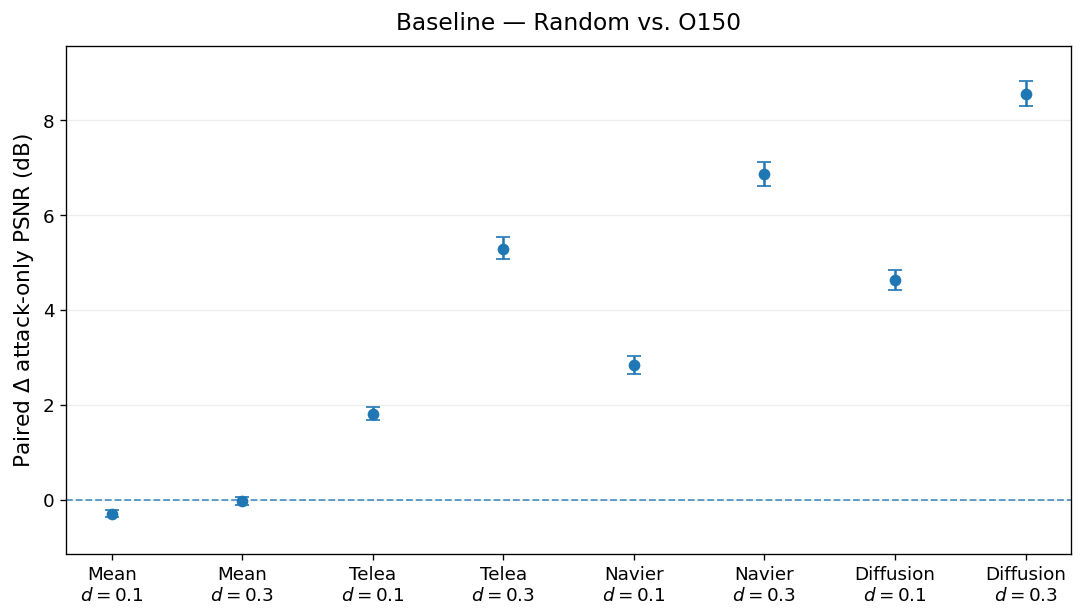

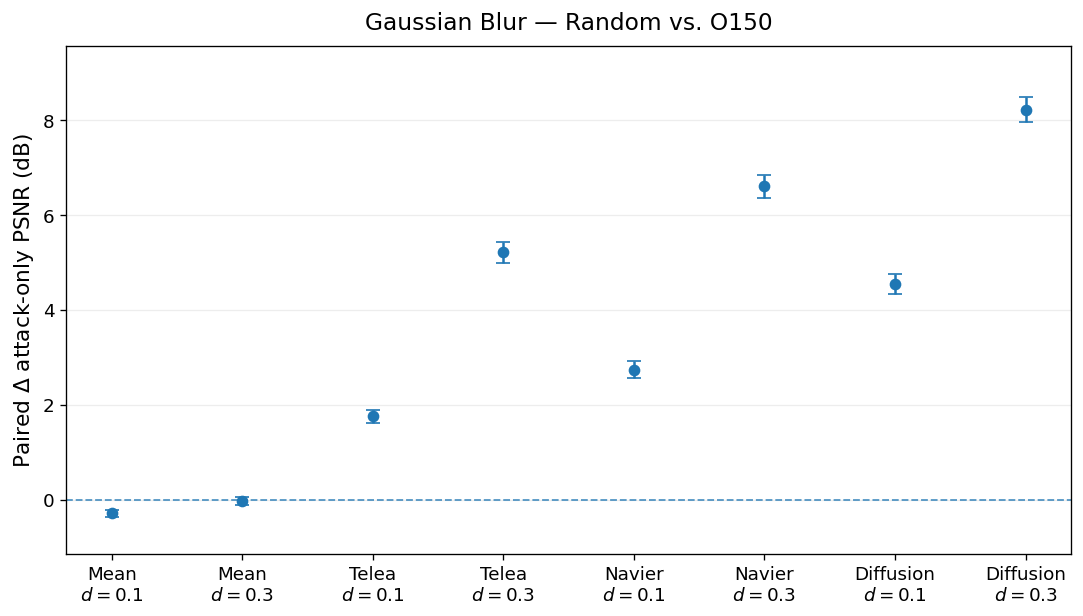

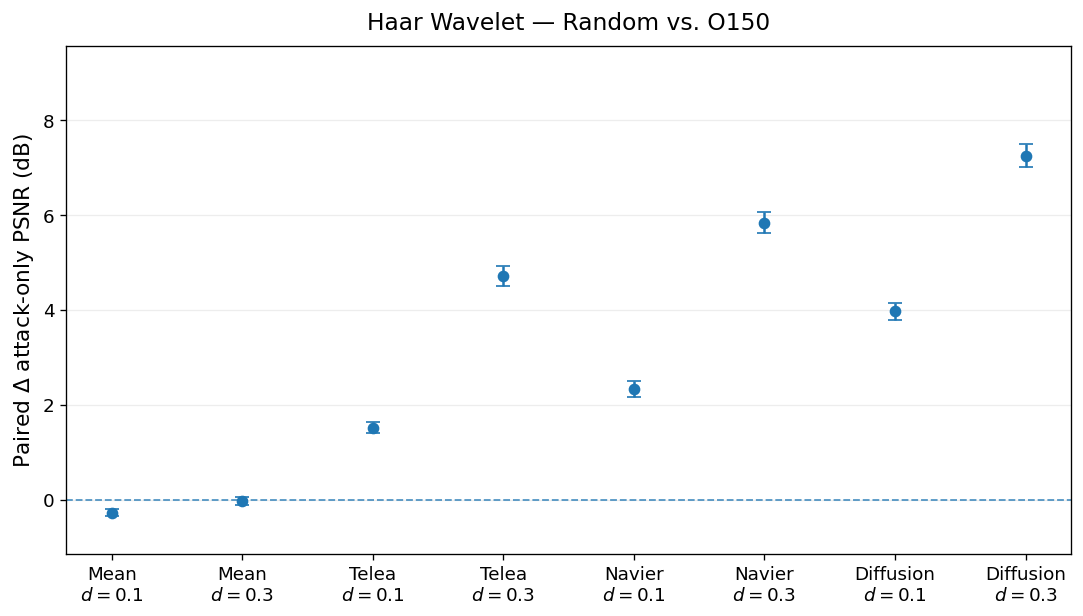

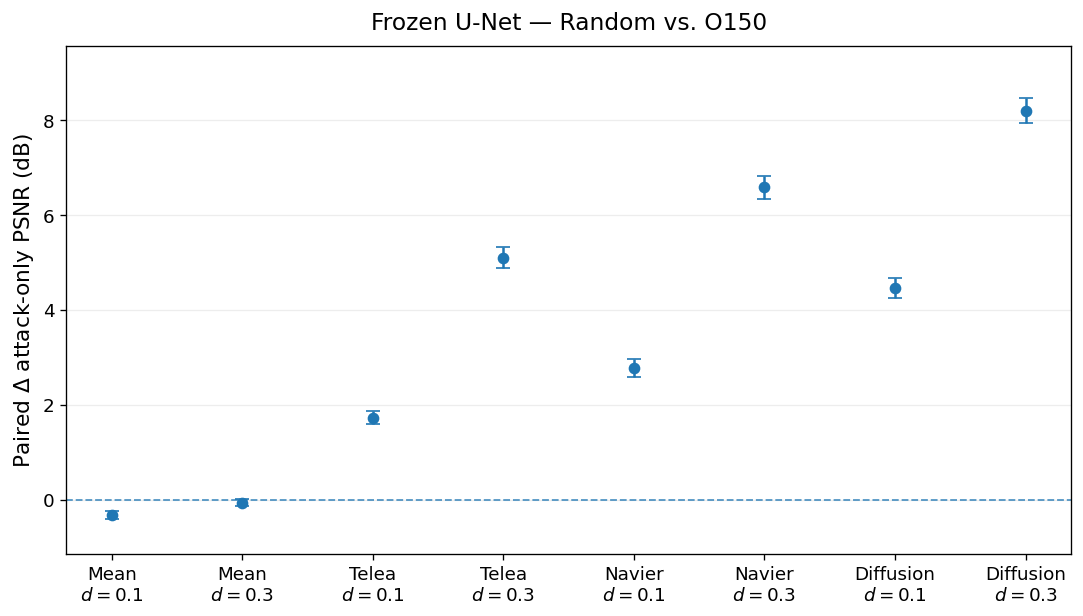

In [15]:
# Reconstruction effect of Random -> O150.
for model in MODEL_ORDER:
    safe_model = (
        model.lower()
        .replace(" ", "_")
    )

    plot_bootstrap_differences(
        model=model,
        comparison="Random -> O150",
        metric="psnr_attack",
        ylabel=(
            "Paired $\\Delta$ attack-only "
            "PSNR (dB)"
        ),
        filename=(
            f"bootstrap_"
            f"{safe_model}_"
            "random_o150_"
            "psnr_attack.pdf"
        ),
    )

plt.show()

saved: /home/keen/HiDDeN/output/figures/bootstrap_baseline_random_o150_ber.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_gaussian_blur_random_o150_ber.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_haar_wavelet_random_o150_ber.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_frozen_unet_random_o150_ber.pdf


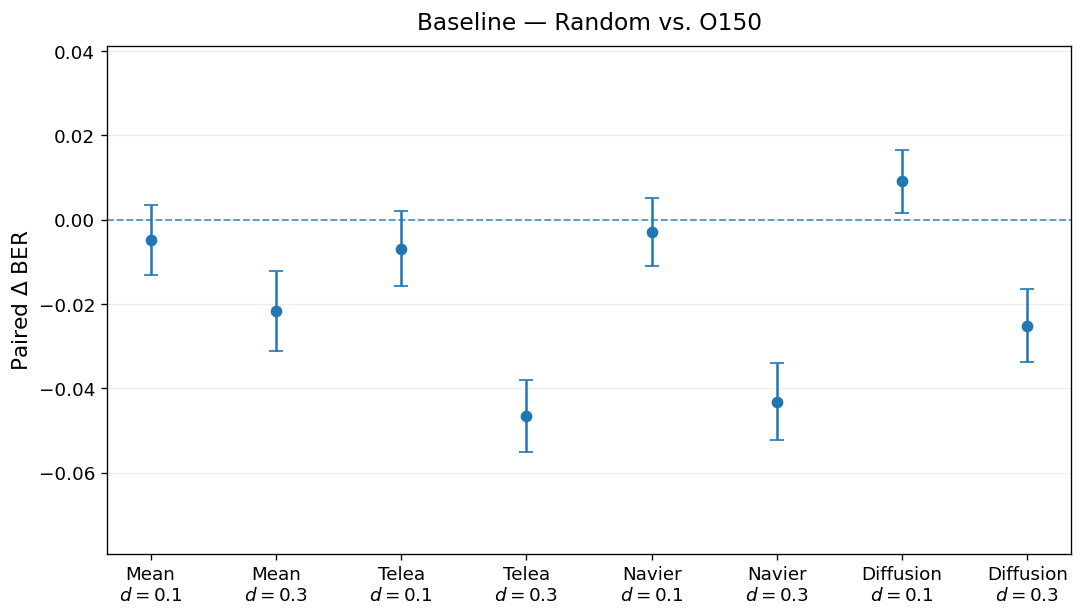

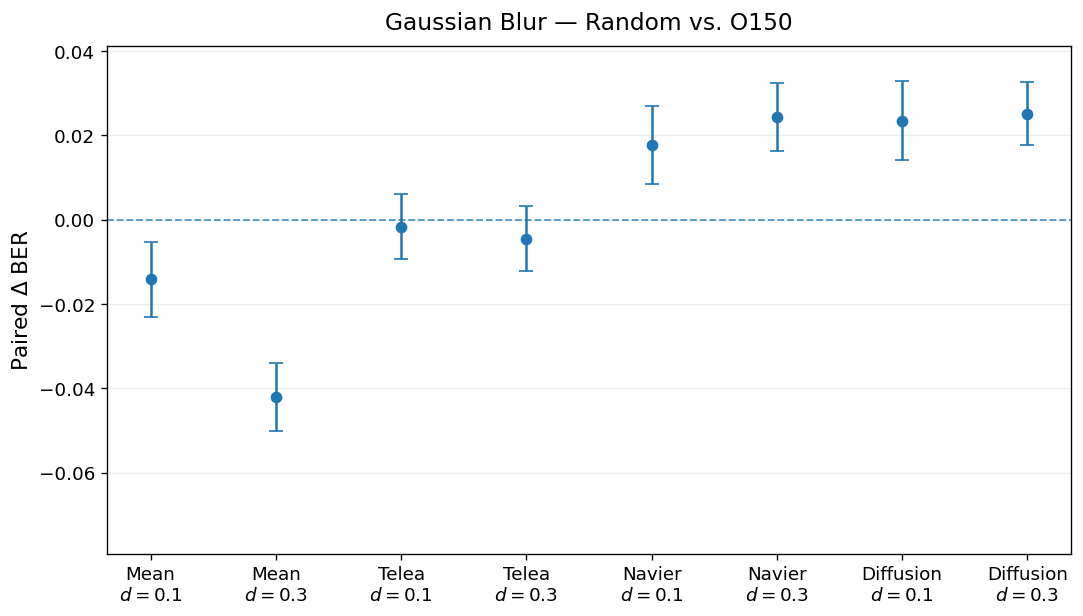

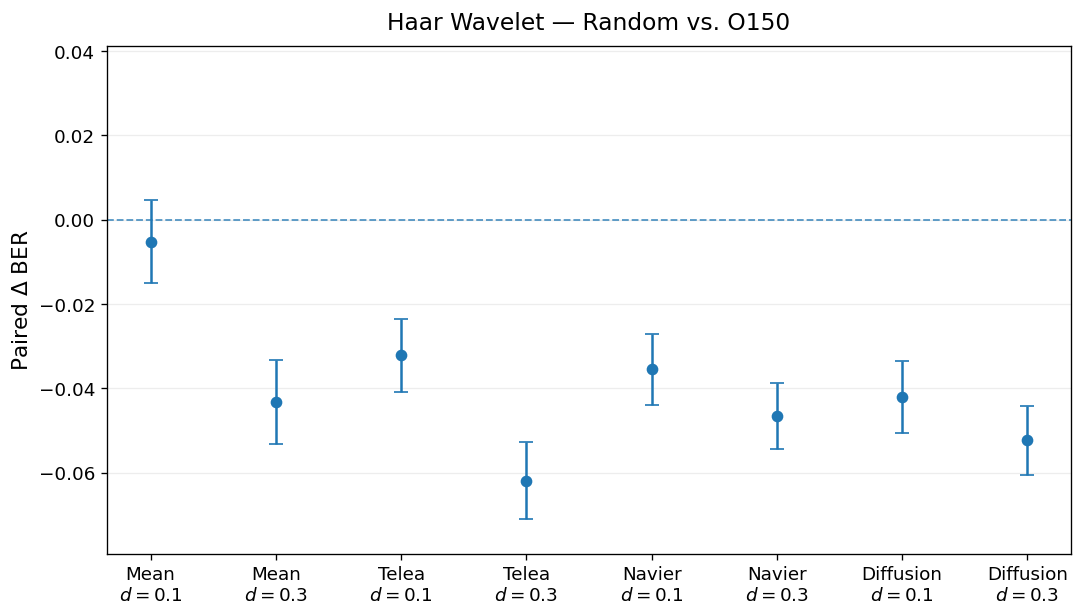

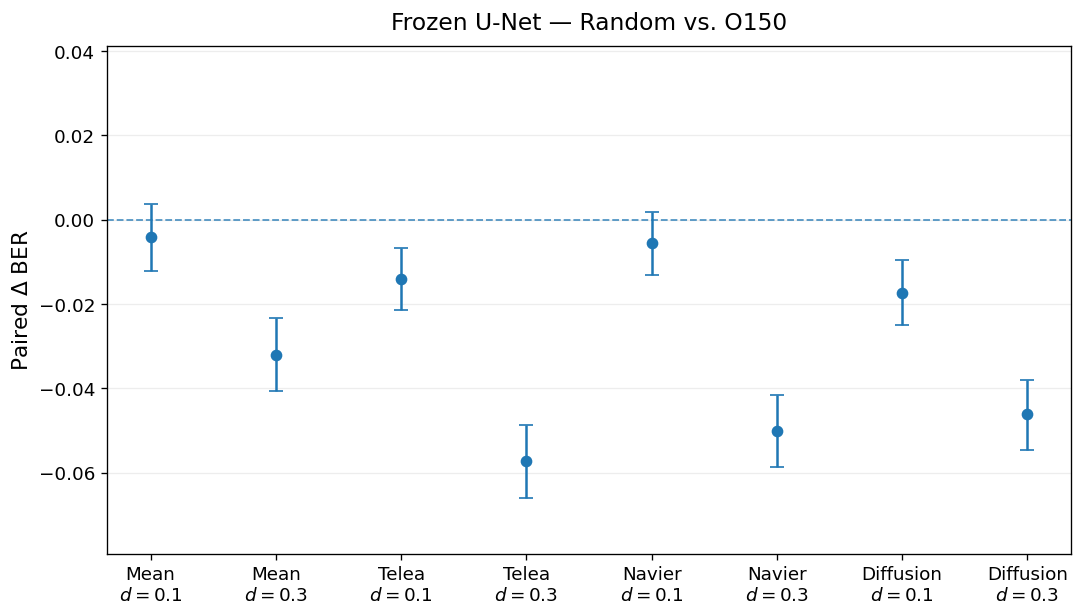

In [16]:
# Watermark-recovery effect of Random -> O150.
for model in MODEL_ORDER:
    safe_model = (
        model.lower()
        .replace(" ", "_")
    )

    plot_bootstrap_differences(
        model=model,
        comparison="Random -> O150",
        metric="ber",
        ylabel="Paired $\\Delta$ BER",
        filename=(
            f"bootstrap_"
            f"{safe_model}_"
            "random_o150_ber.pdf"
        ),
    )

plt.show()

### 8.2 O150 → O300: optimization-budget comparison

saved: /home/keen/HiDDeN/output/figures/bootstrap_baseline_o150_o300_psnr_attack.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_gaussian_blur_o150_o300_psnr_attack.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_haar_wavelet_o150_o300_psnr_attack.pdf
saved: /home/keen/HiDDeN/output/figures/bootstrap_frozen_unet_o150_o300_psnr_attack.pdf


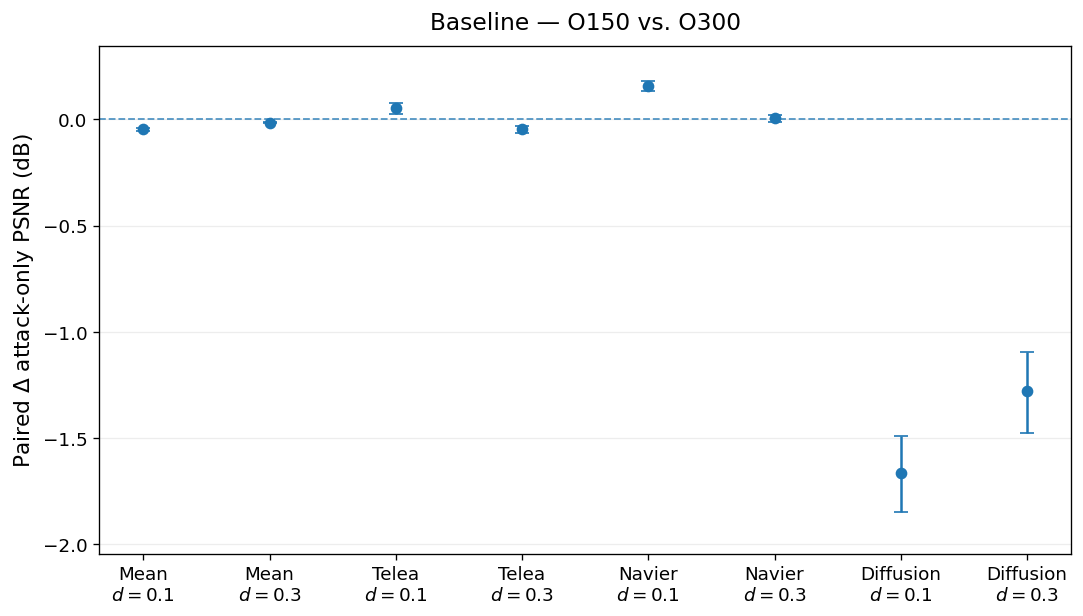

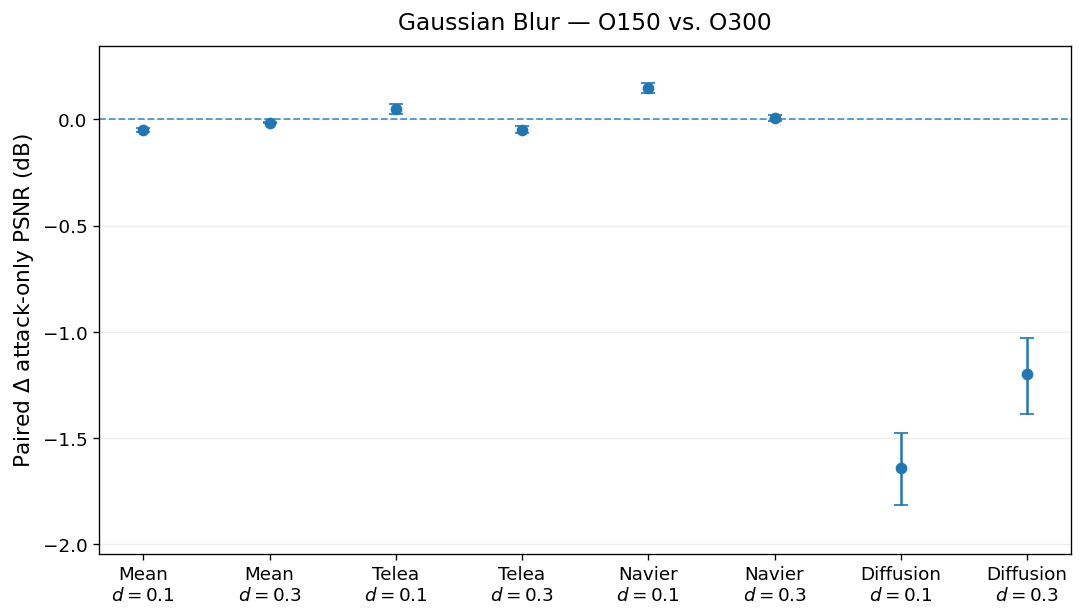

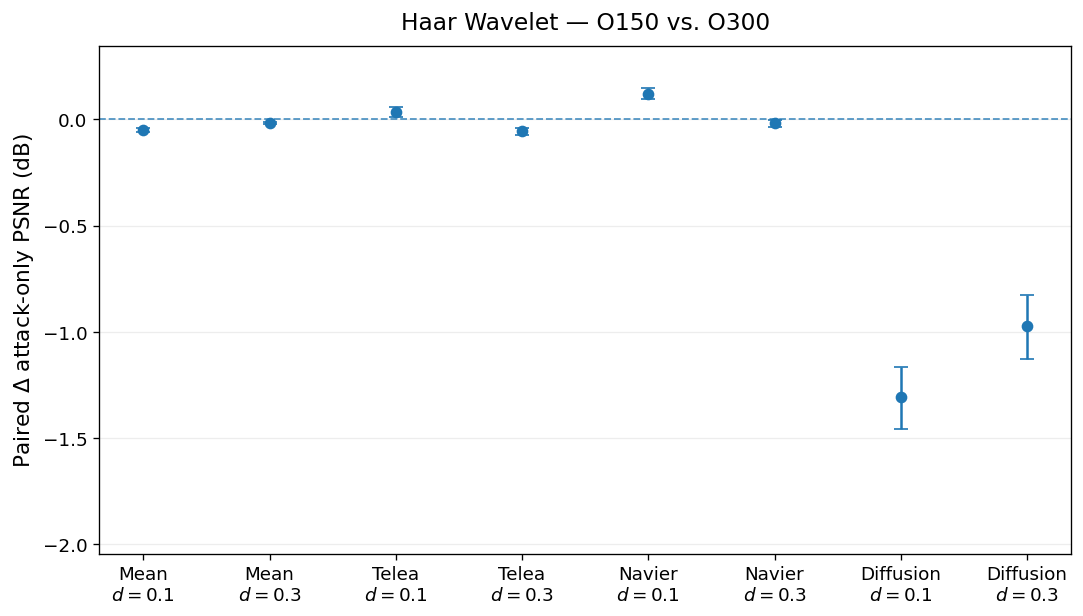

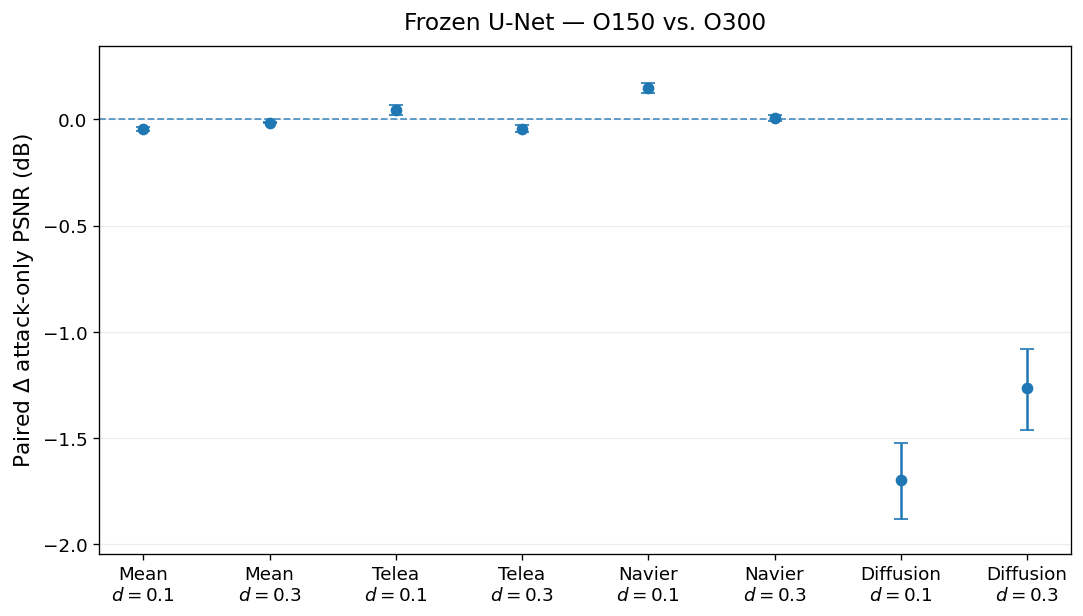

In [17]:
for model in MODEL_ORDER:
    safe_model = (
        model.lower()
        .replace(" ", "_")
    )

    plot_bootstrap_differences(
        model=model,
        comparison="O150 -> O300",
        metric="psnr_attack",
        ylabel=(
            "Paired $\\Delta$ attack-only "
            "PSNR (dB)"
        ),
        filename=(
            f"bootstrap_"
            f"{safe_model}_"
            "o150_o300_"
            "psnr_attack.pdf"
        ),
    )

plt.show()

## 9. Clean validation plots

These plots describe the watermark model before an evaluation attack.

- `PSNR_embed` / `SSIM_embed`: cover → encoded image quality
- `BER`: clean message recovery

In [18]:
def plot_validation_metric(
    metric,
    ylabel,
    filename=None,
):
    subset = validation_df.copy()

    subset["model"] = (
        pd.Categorical(
            subset["model"],
            categories=MODEL_ORDER,
            ordered=True,
        )
    )

    subset = (
        subset
        .sort_values("model")
    )

    fig, ax = plt.subplots()

    ax.bar(
        subset["model"].astype(str),
        subset[metric],
    )

    ax.set_ylabel(
        ylabel
    )

    ax.tick_params(
        axis="x",
        rotation=20,
    )

    ax.grid(
        alpha=0.25,
        axis="y",
    )

    fig.tight_layout()

    if filename is not None:
        save_figure(
            fig,
            filename,
        )

    return fig, ax

In [19]:
# Optional clean-validation figures.

# plot_validation_metric(
#     metric="BER",
#     ylabel="Clean BER",
#     filename="validation_ber.pdf",
# )

# plot_validation_metric(
#     metric="PSNR_embed",
#     ylabel="Embedding PSNR (dB)",
#     filename="validation_psnr_embed.pdf",
# )

# plot_validation_metric(
#     metric="SSIM_embed",
#     ylabel="Embedding SSIM",
#     filename="validation_ssim_embed.pdf",
# )

# plt.show()

## 10. Quick inspection tables

These are useful while writing Results. They do not alter any files.

In [20]:
display(
    validation_df
    .sort_values("model")
    .reset_index(drop=True)
)

display(
    sparse_df[
        (
            sparse_df["model"]
            == "Baseline"
        )
        & (
            sparse_df["attack"]
            == "diffusion"
        )
    ]
    .sort_values(
        [
            "density",
            "mask_type",
        ]
    )
    .reset_index(drop=True)
)

display(
    bootstrap_df[
        (
            bootstrap_df["model"]
            == "3k_baseline"
        )
        & (
            bootstrap_df["attack"]
            == "diffusion"
        )
        & (
            bootstrap_df["metric"]
            .isin(
                [
                    "ber",
                    "psnr_attack",
                    "ssim_attack",
                ]
            )
        )
    ]
    .sort_values(
        [
            "density",
            "comparison",
            "metric",
        ]
    )
    .reset_index(drop=True)
)

,model,PSNR_embed,SSIM_embed,BER
0,Baseline,34.2996,0.9436,0.027333
1,Frozen UNet,33.3698,0.9286,0.025333
2,Gaussian Blur,33.0676,0.9212,0.076333
3,Haar Wavelet,29.7277,0.8960,0.089556


,model,mask_type,density,attack,PSNR_final,SSIM_final,PSNR_attack,SSIM_attack,BER,num_images
0,Baseline,O150,0.1,diffusion,26.800377,0.771776,27.079836,0.764870,0.482222,300
1,Baseline,O300,0.1,diffusion,25.201472,0.752080,25.414132,0.745777,0.478556,300
2,Baseline,Random,0.1,diffusion,22.352642,0.623469,22.448756,0.623811,0.473111,300
3,Baseline,O150,0.3,diffusion,32.381923,0.914890,34.156265,0.916697,0.297333,300
4,Baseline,O300,0.3,diffusion,31.416165,0.906102,32.877115,0.908228,0.300667,300
5,Baseline,Random,0.3,diffusion,25.256151,0.776647,25.601820,0.793005,0.322556,300


,model,attack,density,comparison,metric,n_images,mean_a,mean_b,mean_difference,ci_95_low,ci_95_high,ci_excludes_zero,bootstrap_samples,bootstrap_seed
0,3k_baseline,diffusion,0.1,O150 -> O300,ber,300,0.482222,0.478556,-0.003667,-0.008333,0.000889,False,10000,42
1,3k_baseline,diffusion,0.1,O150 -> O300,psnr_attack,300,27.079836,25.414132,-1.665703,-1.847154,-1.493101,True,10000,42
2,3k_baseline,diffusion,0.1,O150 -> O300,ssim_attack,300,0.764870,0.745777,-0.019093,-0.021563,-0.016776,True,10000,42
3,3k_baseline,diffusion,0.1,Random -> O150,ber,300,0.473111,0.482222,0.009111,0.001556,0.016556,True,10000,42
4,3k_baseline,diffusion,0.1,Random -> O150,psnr_attack,300,22.448756,27.079836,4.631080,4.416505,4.843567,True,10000,42
5,3k_baseline,diffusion,0.1,Random -> O150,ssim_attack,300,0.623811,0.764870,0.141059,0.135046,0.147103,True,10000,42
6,3k_baseline,diffusion,0.1,Random -> O300,ber,300,0.473111,0.478556,0.005444,-0.002333,0.013111,False,10000,42
7,3k_baseline,diffusion,0.1,Random -> O300,psnr_attack,300,22.448756,25.414132,2.965376,2.806255,3.122616,True,10000,42
8,3k_baseline,diffusion,0.1,Random -> O300,ssim_attack,300,0.623811,0.745777,0.121966,0.114550,0.129344,True,10000,42
9,3k_baseline,diffusion,0.3,O150 -> O300,ber,300,0.297333,0.300667,0.003333,-0.001889,0.008556,False,10000,42


## Notes

- Rectangular BER figures use a **shared y-axis range** across all five attacks.
- Rectangular attack-only PSNR figures also use a **shared y-axis range** so the
  reconstruction operators can be compared directly.
- Sparse trade-off figures encode mask type as:
  - Random: black hollow triangle
  - O150: gray hollow circle
  - O300: black hollow circle
- Paired-bootstrap figures use the **same y-axis range across all four models**
  for a given comparison/metric.
- The rectangular CSV contains means only, so these rectangular figures do **not**
  show image-level confidence intervals.
- The sparse paired-bootstrap plots use the already computed 95% bootstrap CIs.
- If you later want 95% CI bands on the rectangular sweep curves, use the
  corresponding `__per_image.json` sweep files to bootstrap each removal-ratio mean.
- PDF remains the default export format because it is convenient for LaTeX and
  preserves vector text and lines.